In [35]:
import dask.dataframe as dd
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

In [36]:
filePaths = ["Data/jane-street-real-time-market-data-forecasting/train.parquet/partition_id=0/part-0.parquet",
                  "Data/jane-street-real-time-market-data-forecasting/train.parquet/partition_id=1/part-0.parquet",
                  "Data/jane-street-real-time-market-data-forecasting/train.parquet/partition_id=2/part-0.parquet",
                  "Data/jane-street-real-time-market-data-forecasting/train.parquet/partition_id=3/part-0.parquet",
                  "Data/jane-street-real-time-market-data-forecasting/train.parquet/partition_id=4/part-0.parquet",
                  "Data/jane-street-real-time-market-data-forecasting/train.parquet/partition_id=5/part-0.parquet",
                  "Data/jane-street-real-time-market-data-forecasting/train.parquet/partition_id=6/part-0.parquet",
                  "Data/jane-street-real-time-market-data-forecasting/train.parquet/partition_id=7/part-0.parquet",
                  "Data/jane-street-real-time-market-data-forecasting/train.parquet/partition_id=8/part-0.parquet",
                  "Data/jane-street-real-time-market-data-forecasting/train.parquet/partition_id=9/part-0.parquet"
                  ]
df = dd.read_parquet(filePaths)

In [37]:
columns = ['feature_08', 'feature_15', 'feature_16', 'feature_17', 'feature_18', 'feature_19', 
               'feature_32', 'feature_33', 'feature_37', 'feature_40', 'feature_41', 'feature_44', 
               'feature_45', 'feature_46', 'feature_47', 'feature_51', 'feature_52', 'feature_54', 
               'feature_55', 'feature_56', 'feature_57', 'feature_58', 'feature_62', 'feature_63', 
               'feature_64', 'feature_66', 'feature_73', 'feature_74', 'feature_75', 'feature_76', 
               'feature_77', 'feature_78']
df = df.dropna(subset=columns)

columns = ['feature_00','feature_01','feature_02','feature_03','feature_04','feature_21','feature_26','feature_27','feature_31','feature_39','feature_42','feature_50','feature_53']
df['feature_0_2_3'] = (df['feature_00'] + df['feature_02'] + df['feature_03']) / 3
df['feature_21_31'] = (df['feature_21'] + df['feature_31']) / 2
df = df.drop(['feature_00','feature_02','feature_03','feature_21','feature_31'], axis=1)
columns = ['feature_0_2_3','feature_21_31']
df = df.dropna(subset=columns)

In [38]:
features = ['feature_0_2_3','feature_01','feature_04','feature_05','feature_06','feature_07','feature_08','feature_09','feature_10','feature_11','feature_12','feature_13','feature_14','feature_15','feature_16','feature_17','feature_18','feature_19','feature_20','feature_22','feature_23','feature_24','feature_25','feature_26','feature_27','feature_28','feature_29','feature_30','feature_21_31','feature_32','feature_33','feature_34','feature_35','feature_36','feature_37','feature_38','feature_39','feature_40','feature_41','feature_42','feature_43','feature_44','feature_45','feature_46','feature_47','feature_48','feature_49','feature_50','feature_51','feature_52','feature_53','feature_54','feature_55','feature_56','feature_57','feature_58','feature_59','feature_60','feature_61','feature_62','feature_63','feature_64','feature_65','feature_66','feature_67','feature_68','feature_69','feature_70','feature_71','feature_72','feature_73','feature_74','feature_75','feature_76','feature_77','feature_78']
responders = ['responder_0','responder_1','responder_2','responder_3','responder_4','responder_5','responder_6','responder_7','responder_8']
target = ['responder_6']

In [39]:
dfFeatures = df[features]
dfResponders = df[responders]
dfTarget = df[target]

In [40]:
sampledf = dfFeatures.sample(frac=0.001)  
sampledf = sampledf.compute()

output_dir = './Plots/Feature Plots'
os.makedirs(output_dir, exist_ok=True)  

for feature in features:
    plt.figure(figsize=(8, 6))
    sns.histplot(sampledf[feature], kde=True, bins=30)
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plot_path = os.path.join(output_dir, f'{feature}.png')
    plt.savefig(plot_path)
    plt.close()

In [41]:
standardizedFeatures = StandardScaler().fit_transform(sampledf[features])
sampleStandardFeatures = pd.DataFrame(standardizedFeatures, columns=features)

In [42]:
sampledf = dfResponders.sample(frac=0.001)  
sampledf = sampledf.compute()

output_dir = './Plots/Responder Plots'
os.makedirs(output_dir, exist_ok=True)  

for responder in responders:
    plt.figure(figsize=(8, 6))
    sns.histplot(sampledf[responder], kde=True, bins=30)
    plt.title(f'Distribution of {responder}')
    plt.xlabel(responder)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plot_path = os.path.join(output_dir, f'{responder}.png')
    plt.savefig(plot_path)
    plt.close()

In [43]:
standardizedResponders = StandardScaler().fit_transform(sampledf[responders])
sampleStandardResponders = pd.DataFrame(standardizedResponders, columns=responders)

In [44]:
corrMatrix = sampleStandardFeatures.corr()
corrMatrix.to_csv('./Info/CorrelationMatrix.csv')


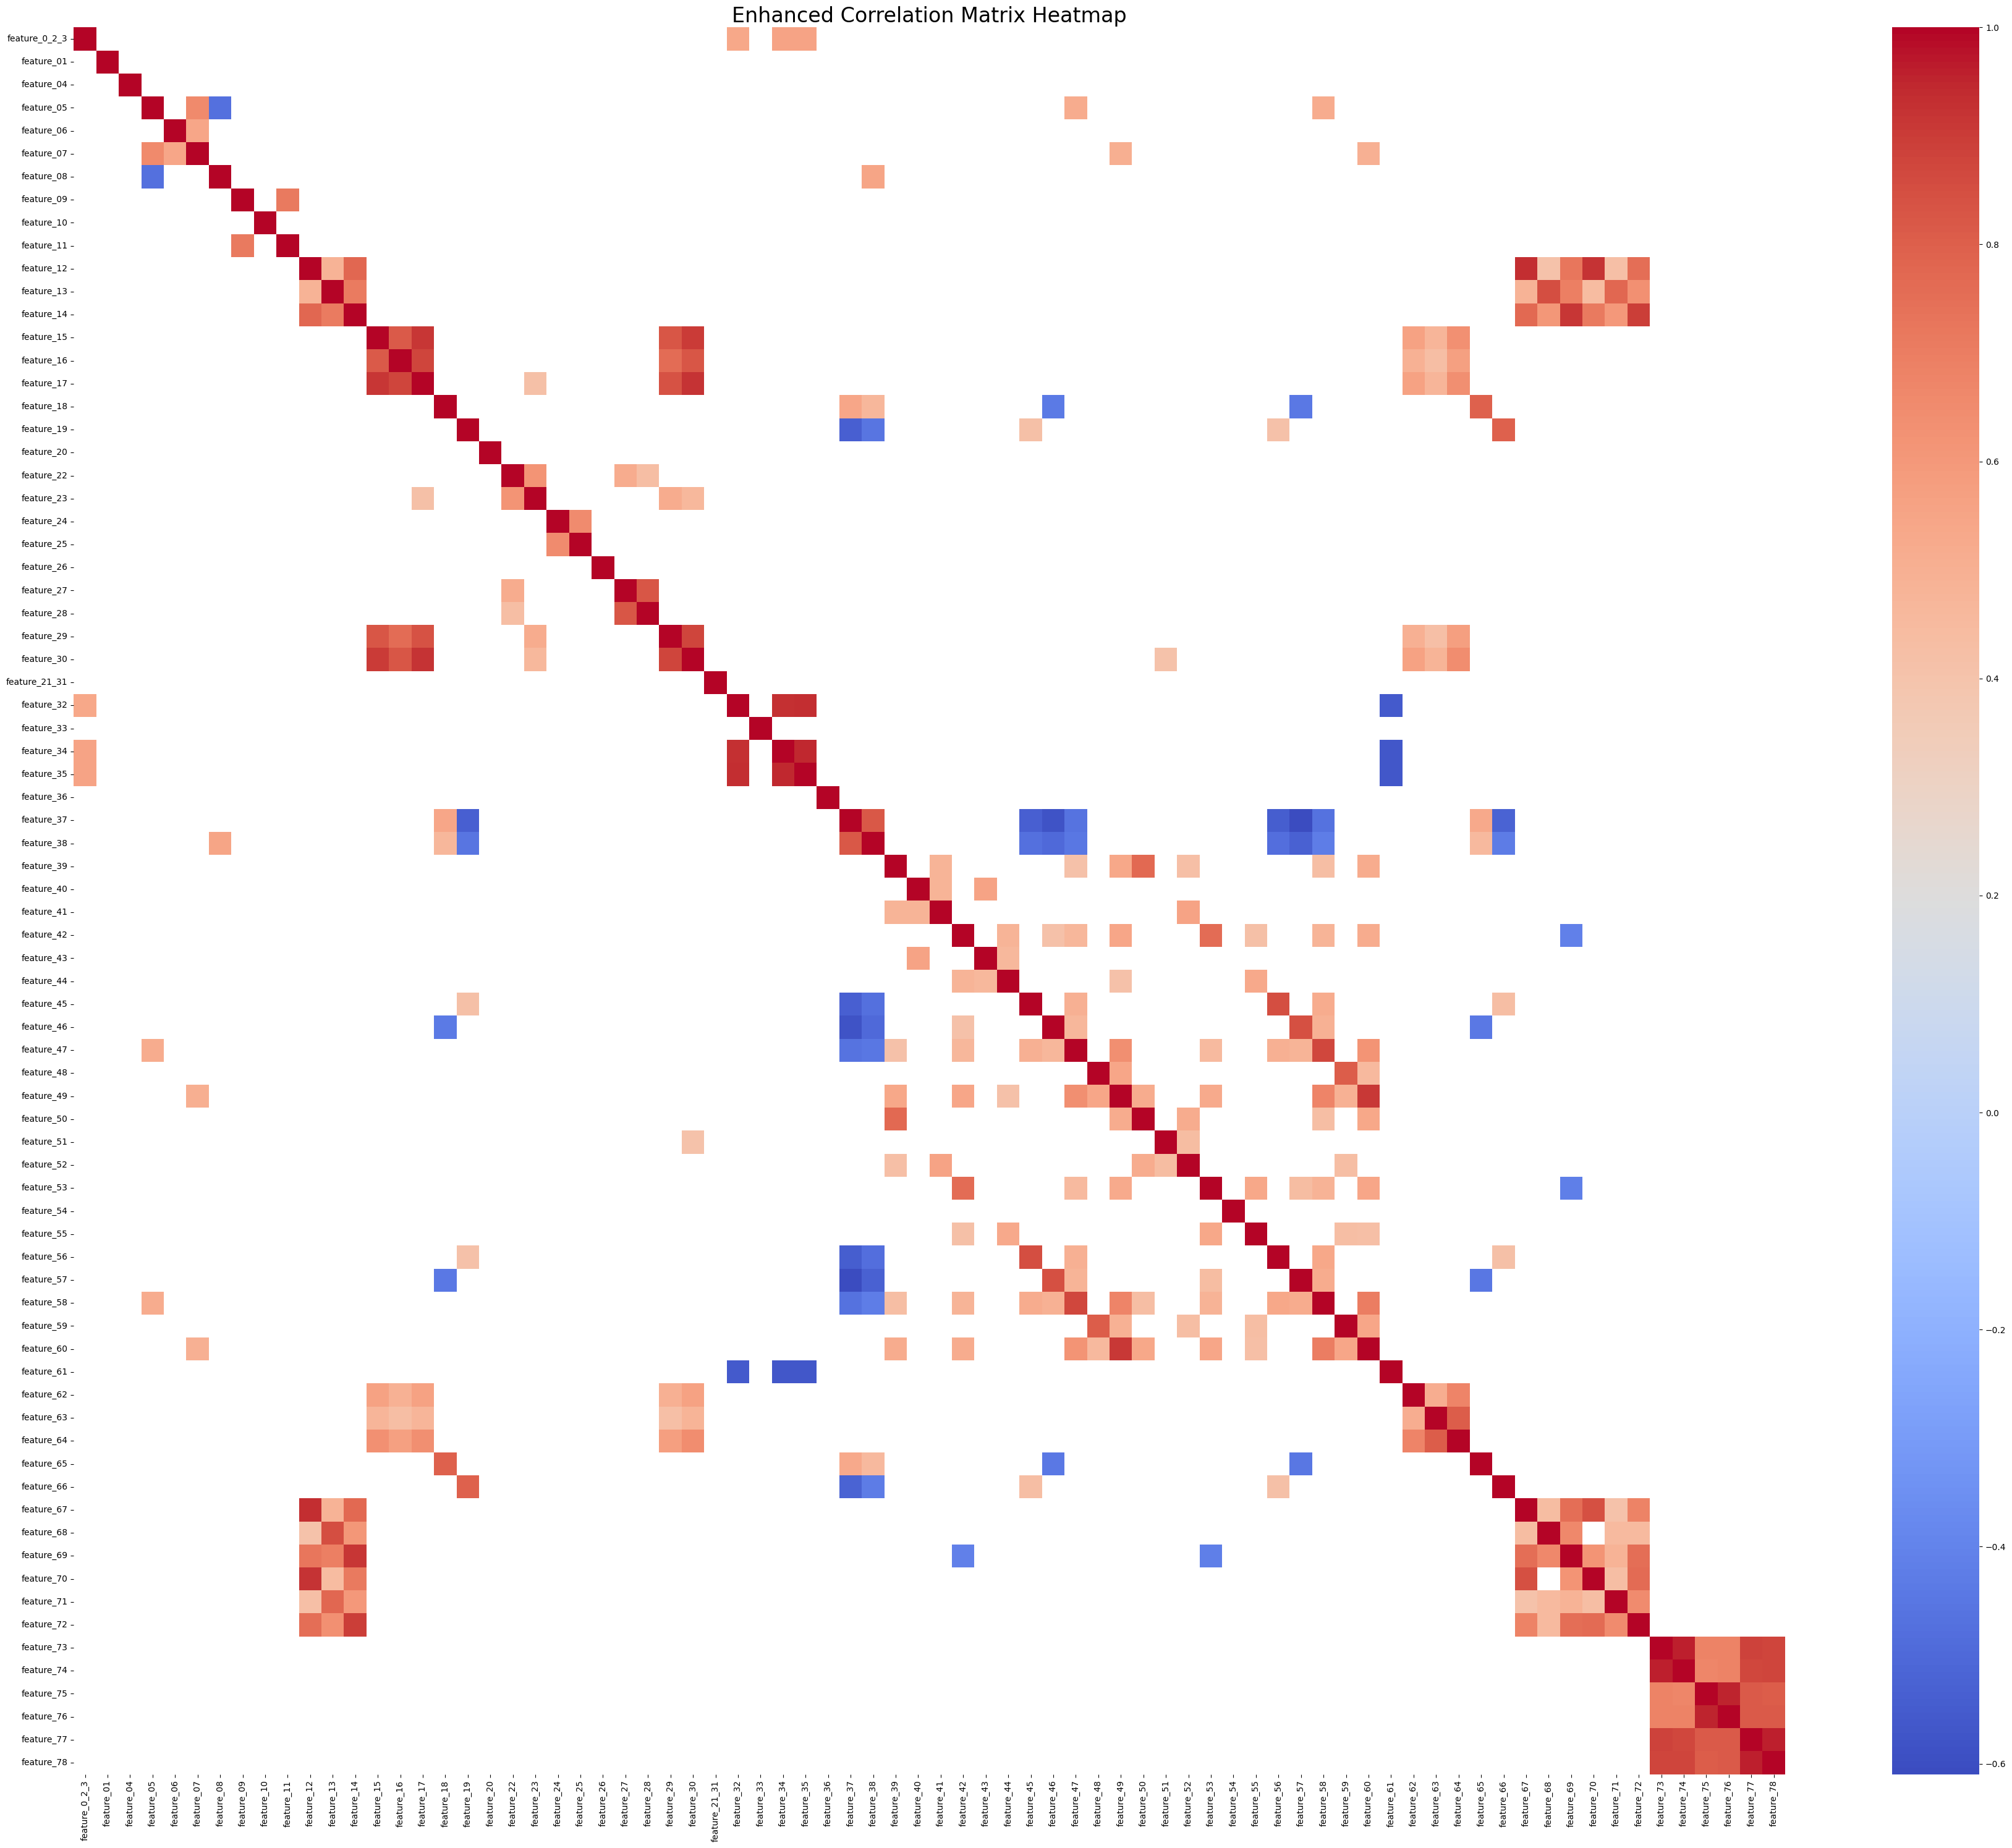

<Figure size 640x480 with 0 Axes>

In [45]:
plt.figure(figsize=(36, 30))
sns.heatmap(
    corrMatrix, 
    annot=False, 
    cmap='coolwarm', 
    cbar=True, 
    mask=corrMatrix.abs() < 0.4
)
plt.xticks(fontsize=10)  
plt.yticks(fontsize=10)  
plt.title('Enhanced Correlation Matrix Heatmap', fontsize=24)
plt.tight_layout()
plt.show()
plt.savefig("./Plots/CorrelationMatrix.png")

In [46]:
# Reduce Dimensionality

In [47]:
sampleStandardFeatures['responder_6'] = sampleStandardResponders['responder_6'].values
correlations = sampleStandardFeatures.corr()
corrR6 = correlations['responder_6'][:-1]  
sortedCorrR6 = corrR6.abs().sort_values(ascending=False)
print("Feature-wise Correlation with Responder 6:")
print(sortedCorrR6.to_string())
with open('./Info/Features-R6 Corr.txt', 'w') as f:
    f.write(sortedCorrR6.to_string())

Feature-wise Correlation with Responder 6:
feature_43       0.015353
feature_40       0.013920
feature_41       0.011244
feature_56       0.011232
feature_08       0.009591
feature_45       0.008734
feature_21_31    0.008326
feature_52       0.007977
feature_39       0.007867
feature_25       0.007697
feature_06       0.007640
feature_63       0.007598
feature_42       0.007537
feature_20       0.007215
feature_19       0.007177
feature_29       0.007038
feature_36       0.006882
feature_15       0.006425
feature_23       0.006324
feature_24       0.006252
feature_07       0.006058
feature_69       0.005753
feature_14       0.005733
feature_22       0.005557
feature_54       0.005468
feature_78       0.005406
feature_17       0.005296
feature_0_2_3    0.005005
feature_67       0.004992
feature_61       0.004904
feature_49       0.004750
feature_04       0.004598
feature_77       0.004578
feature_51       0.004515
feature_30       0.004226
feature_09       0.004217
feature_11       0.00